Wind Reliability Analysis & Baseline Recommendation

Wind power generation is heavily dependent on weather. Based on past wind generation data (January 2025 onwards), we need to analyze historical actual generation of wind and recommend how many MW of wind power can safely/reliably be planned for by the grid operators to meet electricity demand.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import httpx
from datetime import datetime

plt.style.use('ggplot')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
BASE_URL = "https://data.elexon.co.uk/bmrs/api/v1"
start_date = "2025-01-01"
end_date = datetime.now().strftime("%Y-%m-%d")

print("Fetching Actuals...")
res_act = httpx.get(f"{BASE_URL}/datasets/FUELHH/stream", params={
    "settlementDateFrom": start_date,
    "settlementDateTo": end_date,
    "fuelType": "WIND"
}, timeout=60)
actuals_data = [x for x in res_act.json() if x.get('fuelType') == 'WIND']
df_actuals = pd.DataFrame(actuals_data)
df_actuals['startTime'] = pd.to_datetime(df_actuals['startTime'], utc=True)
df_actuals['actual_mw'] = df_actuals['generation'].astype(float)
df_actuals = df_actuals.sort_values('startTime').reset_index(drop=True)

print(f"Loaded {len(df_actuals)} half-hourly records of actual wind generation.")

Fetching Actuals...
Loaded 21234 half-hourly records of actual wind generation.


1. Distribution of Actual Wind Generation

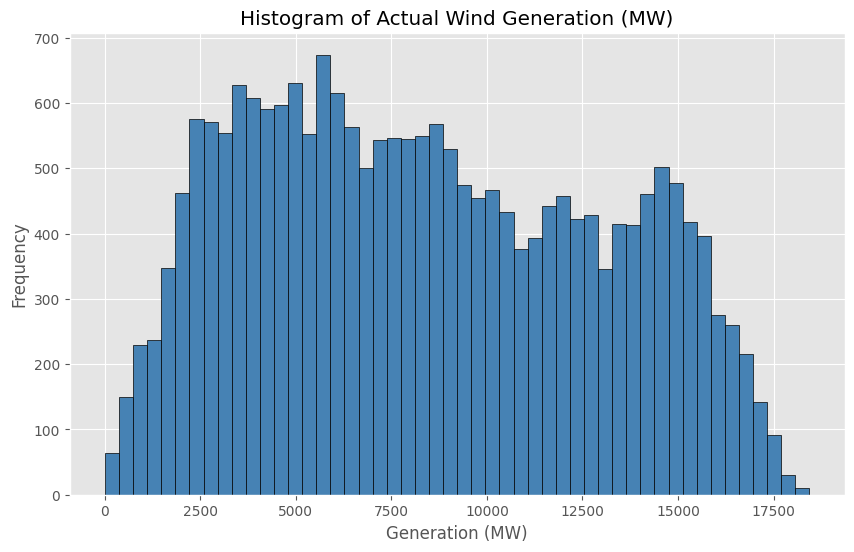

In [3]:
df_actuals['actual_mw'].hist(bins=50, color='steelblue', edgecolor='black')
plt.title('Histogram of Actual Wind Generation (MW)')
plt.xlabel('Generation (MW)')
plt.ylabel('Frequency')
plt.show()

2. Exceedance Probability (ECDF Analysis)
An exceedance curve is crucial for reliability. It tells grid operators "Wind generation was at least X MW for exactly Y% of the time."

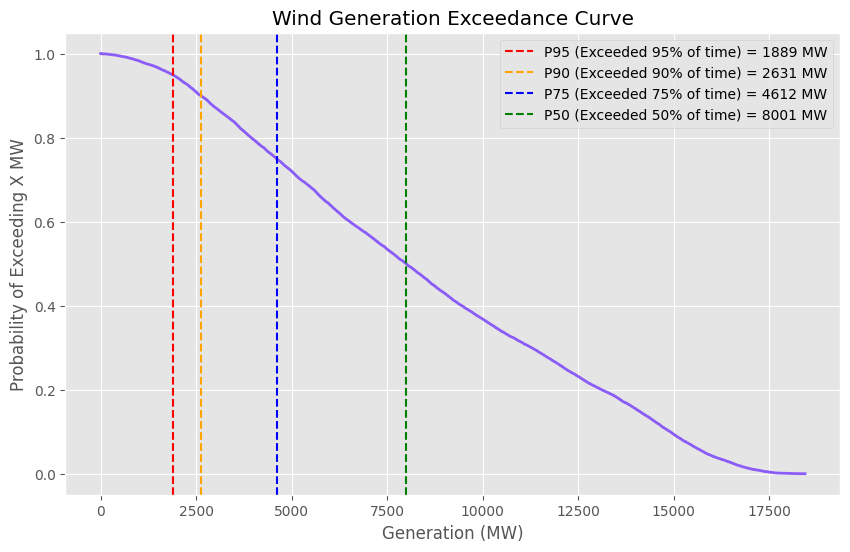

Exceedance Summary:
95% of the time, the grid received at least 1889 MW.
90% of the time, the grid received at least 2631 MW.
75% of the time, the grid received at least 4612 MW.
50% of the time, the grid received at least 8001 MW.


In [4]:
sorted_generations = np.sort(df_actuals['actual_mw'].dropna())
exceedance_prob = 1.0 - np.arange(1, len(sorted_generations) + 1) / len(sorted_generations)

plt.plot(sorted_generations, exceedance_prob, color='#8b5cf6', linewidth=2)
plt.title('Wind Generation Exceedance Curve')
plt.xlabel('Generation (MW)')
plt.ylabel('Probability of Exceeding X MW')
plt.grid(True)

percentiles = [95, 90, 75, 50]
colors = ['red', 'orange', 'blue', 'green']
for p, c in zip(percentiles, colors):
    val = np.percentile(sorted_generations, 100 - p)
    plt.axvline(val, color=c, linestyle='--', label=f'P{p} (Exceeded {p}% of time) = {val:.0f} MW')

plt.legend()
plt.show()

print("Exceedance Summary:")
for p in percentiles:
    val = np.percentile(sorted_generations, 100 - p)
    print(f"{p}% of the time, the grid received at least {val:.0f} MW.")

3. Reliability Recommendation
Based on the analysis, how many MW of wind power can we *reliably* expect to be available?

Analytical conclusions and Recommendation here:
    ECDF analysis highlights that although median wind generation (~8,001 MW) appears strong, it is unreliable for grid planning. Adopting the conservative P95 baseline of 1,889 MW ensures dependable supply 95% of the time, reducing shortfall risks and limiting dependence on expensive, high-emission backup power sources.

